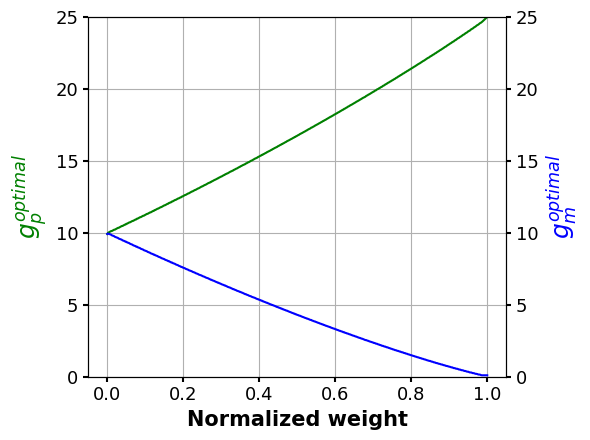

In [1]:
from mapping_optimizer import DriftMappingOptimizer
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

target_time = 1e+5 * 20#2.628e+6
t0 = 20
tau_target = 1 + target_time / t0

opt = DriftMappingOptimizer(
    g_min=0.1,
    g_max=25,
    N=500,
    tau_target=tau_target,
    nu_amp=None,
    distortion=0.0,
    sigma_prog=0.0,
    sigma_read=0.0,
    sigma_nu=0.0,
    )
amp_split = 1.00
opt.nu_amp = amp_split * opt.nu_amp
gp_opt, gm_opt = opt.brute_force_mapping()

W0_vals = opt.beta * (gp_opt - gm_opt)
# plt.rcParams['font.family'] = 'sayd
fig, ax1 = plt.subplots(figsize=(6,4.5))
ax2 = ax1.twinx()
ax1.plot(W0_vals, gp_opt, 'g-', label='$g_p^{opt}$')
ax2.plot(W0_vals, gm_opt, 'b-', label='$g_m^{opt}$')
ax1.set_xlabel('Normalized weight', fontsize=15, fontweight='bold')
ax1.set_ylabel('$g_p^{optimal}$', color='g', fontsize=18, fontweight='bold')
ax2.set_ylabel('$g_m^{optimal}$', color='b', fontsize=18, fontweight='bold')
ax1.set_ylim(0, opt.g_max)
ax2.set_ylim(0, opt.g_max)
ax1.tick_params(axis='both', labelsize=13, width=1.5)
ax2.tick_params(axis='both', labelsize=13, width=1.5)

# for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
#     label.set_fontweight('bold')
# plt.title('Weight vs. Optimal Conductance Pair')
ax1.grid(True)
fig.tight_layout()
plt.savefig("weight-gpgm.png", dpi=300, bbox_inches='tight')
plt.show()



In [2]:
# subfunctions
def nu(g):
    """ Calculate the drift coefficient nu for a given conductance g. """
    g_rel = (g - opt.g_min) / (opt.g_max - opt.g_min)
    return (-0.0155 * np.log(g_rel**1.0 + 0.00762)) + 0.0244
    #return -0.0757 * g_rel + 0.1

def drift(g, tau_val):
    """ Calculate the drift coefficient for a given conductance g. """
    return g * (tau_val ** -nu(g))

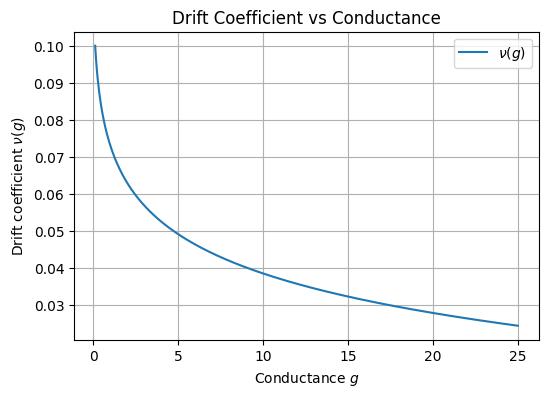

In [3]:
test_g = np.linspace(opt.g_min, opt.g_max, opt.N)  # conductance values for testing
# Plot G-Nu relationship
plt.figure(figsize=(6, 4))
plt.plot(test_g, opt.nu(test_g), label=r'$\nu(g)$')
plt.xlabel('Conductance $g$')
plt.ylabel(r'Drift coefficient $\nu(g)$')
plt.title('Drift Coefficient vs Conductance')
plt.grid(True)
plt.legend()
plt.show()

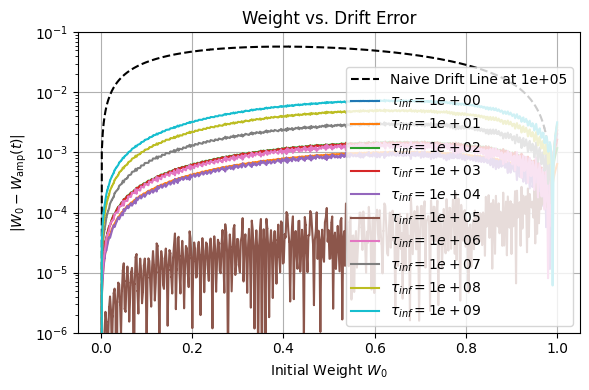

[ 2.64268112 12.1806845  10.00479516] [  2.64268112 -12.7193155   10.00479516]


In [4]:
tau_inf = [1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
W0_vals, delta_avgs = opt.eval_compensation(tau_inf)

gp_naive = W0_vals / opt.beta + opt.g_min
gm_naive = opt.g_min

plt.figure(figsize=(6,4))
""" gp_naive_drifted = drift(gp_naive, tau_inf[-1])
gm_naive_drifted = drift(gm_naive, tau_inf[-1])
naive_amped_wval = opt.beta * (tau_inf[-1]**opt.nu_amp) * (gp_naive_drifted - gm_naive_drifted)
plt.plot(W0_vals, abs(W0_vals - naive_amped_wval), 'k--', label='Naive Drift Line at {:.0e}'.format(tau_inf[-1])) """
gp_naive_drifted = drift(gp_naive, opt.tau_target)
gm_naive_drifted = drift(gm_naive, opt.tau_target)
naive_amped_wval = opt.beta * (opt.tau_target**opt.nu_amp) * (gp_naive_drifted - gm_naive_drifted)
plt.plot(W0_vals, abs(W0_vals - naive_amped_wval), 'k--', label='Naive Drift Line at {:.0e}'.format(opt.tau_target))

for i in range(len(tau_inf)):
    plt.plot(W0_vals, delta_avgs[i], label=f'$\\tau_{{inf}} = {tau_inf[i]:.0e}$')

plt.xlabel('Initial Weight $W_0$')
plt.ylabel('$|W_0 - W_{\\mathrm{amp}}(t)|$')
plt.yscale('log')
plt.ylim(1e-6, 1e-1)
plt.title('Weight vs. Drift Error')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

opt.save_mapping_to_csv('mapping_results.csv')
gp_coeffs, gm_coeffs = opt.fit_quadratic_mapping()
print(gp_coeffs, gm_coeffs)

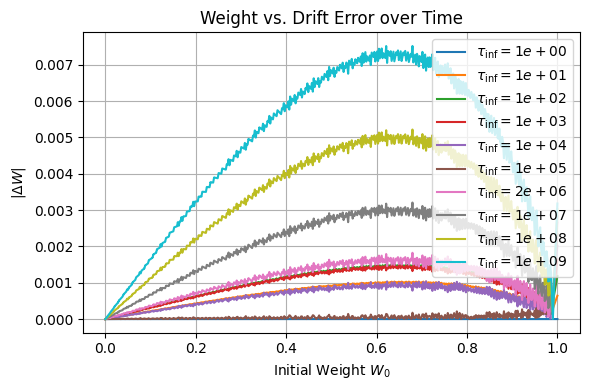

        tau_inf       auc  peak_val  peak_pos
0  1.000000e+00  0.000000  0.000000  0.000000
1  1.000000e+01  0.000671  0.001034  0.693387
2  1.000000e+02  0.000979  0.001520  0.623246
3  1.000000e+03  0.000955  0.001507  0.709419
4  1.000000e+04  0.000625  0.001038  0.709419
5  1.000000e+05  0.000066  0.000214  0.881764
6  1.577001e+06  0.001079  0.001824  0.679359
7  1.000000e+07  0.001979  0.003206  0.679359
8  1.000000e+08  0.003291  0.005215  0.679359
9  1.000000e+09  0.004797  0.007514  0.679359
[ 2.64268112 12.1806845  10.00479516] [  2.64268112 -12.7193155   10.00479516]


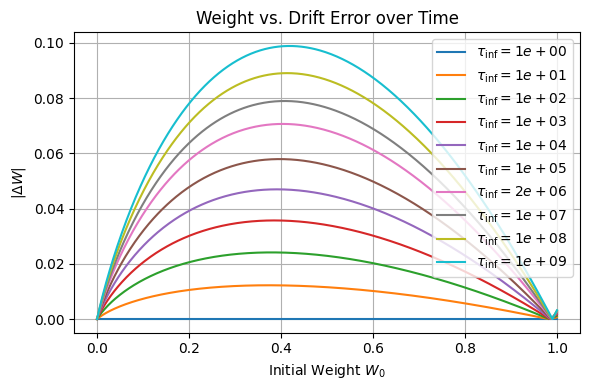

        tau_inf       auc  peak_val  peak_pos
0  1.000000e+00  0.000000  0.000000  0.000000
1  1.000000e+01  0.008144  0.012232  0.372745
2  1.000000e+02  0.016089  0.024131  0.378758
3  1.000000e+03  0.023834  0.035706  0.384770
4  1.000000e+04  0.031380  0.046965  0.390782
5  1.000000e+05  0.038729  0.057918  0.396794
6  1.577001e+06  0.047276  0.070649  0.402806
7  1.000000e+07  0.052847  0.078945  0.408818
8  1.000000e+08  0.059623  0.089040  0.412826
9  1.000000e+09  0.066217  0.098867  0.418838


In [5]:
tau_inf = [1, 1e1, 1e2, 1e3, 1e4, 1e5, 3.154e7/20+1, 1e7, 1e8, 1e9]
df_metrics = opt.analyze_compensation(tau_inf)
print(df_metrics)
#df_metrics.to_csv(f'compensation_analysis_{amp_split:.3e}.csv', index=False)

opt.save_mapping_to_csv('mapping_results.csv')
gp_coeffs, gm_coeffs = opt.fit_quadratic_mapping()
print(gp_coeffs, gm_coeffs)

opt.opt_gp = np.linspace(opt.g_min, opt.g_max, 500)
opt.opt_gm = np.linspace(opt.g_min, opt.g_min, 500)

naive_df_metric = opt.analyze_compensation(tau_inf)
print(naive_df_metric)

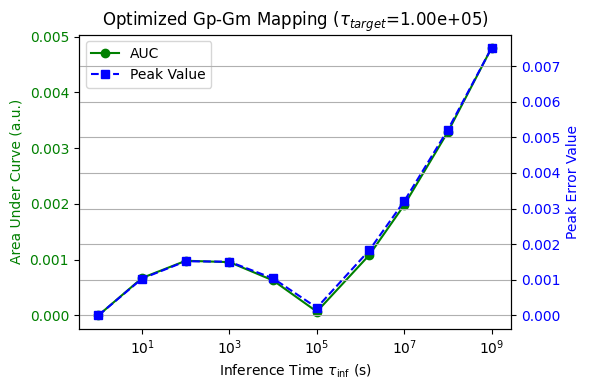

In [6]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

# Plot AUC on left y-axis
ax1.plot(df_metrics['tau_inf'], df_metrics['auc'], 'g-', marker='o', label='AUC')
ax1.set_xlabel(r'Inference Time $\tau_{\mathrm{inf}}$ (s)')
ax1.set_ylabel('Area Under Curve (a.u.)', color='g')
ax1.tick_params(axis='y', labelcolor='g')
ax1.set_xscale('log')

# Plot Peak Value on right y-axis
ax2.plot(df_metrics['tau_inf'], df_metrics['peak_val'], 'b--', marker='s', label='Peak Value')
ax2.set_ylabel('Peak Error Value', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.set_xscale('log')

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title(r'Optimized Gp-Gm Mapping ($\tau_{{target}}$={:.2e})'.format(opt.tau_target))
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.savefig("nontargeterror.png", dpi=300, bbox_inches='tight')
plt.show()

DejaVu Sans


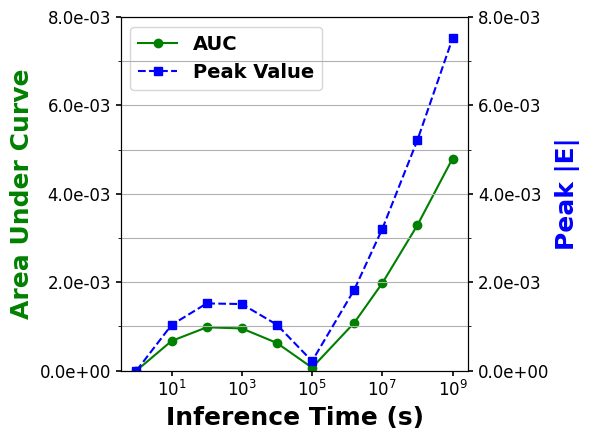

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib import font_manager as fm, rcParams

preferred = ['Helvetica', 'Helvetica Neue', 'Arial', 'Nimbus Sans', 'TeX Gyre Heros',
             'Liberation Sans', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
for name in preferred:
    if name in available:
        rcParams['font.family'] = name
        print(name)
        break
else:
    rcParams['font.family'] = 'DejaVu Sans'  # guaranteed in Matplotlib

# make math text match sans as well (since you use $...$)
rcParams['mathtext.fontset'] = 'dejavusans'
# --- helpers ---
# sci_fmt = '%.3e'  # change to '%.2e', '%.1e', etc., if you prefer
def sci_formatter(x, pos):
    return f"{x:.1e}"   # correct Python formatting

# Global font family (Helvetica with Arial fallback)
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']

fig, ax1 = plt.subplots(figsize=(6, 4.5))
ax2 = ax1.twinx()

# Left y-axis (AUC)
ax1.plot(df_metrics['tau_inf'], df_metrics['auc'], 'g-', marker='o', label='AUC')
ax1.set_xlabel(r'Inference Time (s)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Area Under Curve', color='g', fontsize=18, fontweight='bold')
ax1.set_xscale('log')
ax1.set_ylim(0, 0.008)

# Right y-axis (Peak Value)
ax2.plot(df_metrics['tau_inf'], df_metrics['peak_val'], 'b--', marker='s', label='Peak Value')
ax2.set_ylabel(r'Peak |E|', color='b', fontsize=18, fontweight='bold')
ax2.set_xscale('log')
ax2.set_ylim(0, 0.008)

# === y ticks: every 0.002, formatted in %e ===
y_locator = MultipleLocator(0.002)
y_formatter = FuncFormatter(sci_formatter)

ax1.yaxis.set_major_locator(y_locator)
ax1.yaxis.set_major_formatter(y_formatter)

ax2.yaxis.set_major_locator(y_locator)
ax2.yaxis.set_major_formatter(y_formatter)

# Tick styling (size 15, bold)
ax1.tick_params(axis='both', labelsize=12, width=1.2)
ax2.tick_params(axis='y', labelsize=12, width=1.2)
# for lbl in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
#     lbl.set_fontweight('bold')

# Legend (combine both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           prop={'size': 14, 'weight': 'bold'})

ax1.yaxis.set_minor_locator(MultipleLocator(0.001))
ax2.yaxis.set_minor_locator(MultipleLocator(0.001))

plt.grid(True, which='both', axis='y')
fig.tight_layout()

fig.savefig("nontargeterror.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
